# Chapter 7 — Score SDE on MNIST (28×28)

**Theory reference**: `quickguide.tex` Chapter 3.

### What this notebook covers
1. **Train NCSN** on MNIST with a geometric noise schedule; visualize the learned score field
2. **Annealed Langevin dynamics** sampling chain $\sigma_1 \to \cdots \to \sigma_L$
3. **Train VE-SDE** (continuous-time) on MNIST
4. **Reverse SDE vs. probability flow ODE** — stochastic vs. deterministic sampling
5. **NCSN vs. VE-SDE vs. DDPM** side-by-side comparison

### Key equations
**DSM loss** (quickguide Thm 3.3):
$$\mathcal{L}_{\text{DSM}}(\theta,\sigma) = \mathbb{E}_{x_0,\varepsilon}\!\left[\left\|s_\theta(x_0+\sigma\varepsilon,\sigma) + \frac{\varepsilon}{\sigma}\right\|^2\right]$$

**NCSN loss** (geometric multi-scale weighting):
$$\mathcal{L}_{\text{NCSN}} = \sum_{i=1}^L \sigma_i^2 \cdot \mathcal{L}_{\text{DSM}}(\theta,\sigma_i)$$

**Annealed Langevin** (quickguide Def 3.4):
$$x_{k+1} = x_k + \tfrac{\alpha_i}{2}\,s_\theta(x_k,\sigma_i) + \sqrt{\alpha_i}\,z_k, \qquad \alpha_i = \eta\left(\frac{\sigma_i}{\sigma_L}\right)^2$$

**VE-SDE forward**: $\mathrm{d}x = g(t)\,\mathrm{d}W,\quad g(t) = \sigma(t)\sqrt{2\log(\sigma_{\max}/\sigma_{\min})}$

**Reverse SDE**: $\mathrm{d}x = -g^2(t)\,s_\theta(x,t)\,\mathrm{d}t + g(t)\,\mathrm{d}\bar{W}$

**Probability flow ODE** (same marginals, deterministic):
$$\frac{\mathrm{d}x}{\mathrm{d}t} = -\tfrac{1}{2}g^2(t)\,s_\theta(x,t)$$

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path('..').resolve()))

import numpy as np
import torch
import matplotlib.pyplot as plt
%matplotlib inline
plt.rcParams['figure.dpi'] = 120

if torch.cuda.is_available():
    DEVICE = 'cuda'
elif torch.backends.mps.is_available():
    DEVICE = 'mps'
else:
    DEVICE = 'cpu'
print(f'Device: {DEVICE}')

Device: mps


## 0  Data

In [2]:
from diffusion_lab.data import get_mnist_loader, denormalize
from diffusion_lab.utils import show_grid

train_loader = get_mnist_loader(split='train', batch_size=128, num_workers=0)
test_loader  = get_mnist_loader(split='test',  batch_size=64,  num_workers=0)

x_batch, _ = next(iter(train_loader))
print(f'Batch shape: {x_batch.shape}  range: [{x_batch.min():.2f}, {x_batch.max():.2f}]')

Batch shape: torch.Size([128, 1, 28, 28])  range: [-1.00, 1.00]


## 1  NCSN — Noise Conditional Score Network

A geometric noise schedule $\sigma_1 > \sigma_2 > \cdots > \sigma_L$ is used,  
with $\sigma_1 \approx \max_{x,x'}\|x-x'\|$ (diameter of data manifold) and $\sigma_L \approx 0$.

In [3]:
from diffusion_lab.nn     import SmallUNet
from diffusion_lab.models import NCSN

L         = 10
SIGMA_MIN = 0.01
SIGMA_MAX = 1.0    # covers the [-1,1] pixel range; σ=1 is already very noisy

sigmas = torch.exp(torch.linspace(np.log(SIGMA_MAX), np.log(SIGMA_MIN), L))
print('Noise schedule σ_1 → σ_L:')
print([f'{s:.4f}' for s in sigmas.tolist()])

# SmallUNet as the score network
score_net = SmallUNet(
    in_channels=1,
    out_channels=1,
    base_channels=32,
    time_embed_dim=128,
    dropout=0.1,
).to(DEVICE)

ncsn = NCSN(score_net, sigmas=sigmas).to(DEVICE)

n_params = sum(p.numel() for p in score_net.parameters())
print(f'Score network parameters: {n_params:,}')

Noise schedule σ_1 → σ_L:
['1.0000', '0.5995', '0.3594', '0.2154', '0.1292', '0.0774', '0.0464', '0.0278', '0.0167', '0.0100']
Score network parameters: 1,590,017


### 1a  Visualize noisy MNIST at each $\sigma_i$

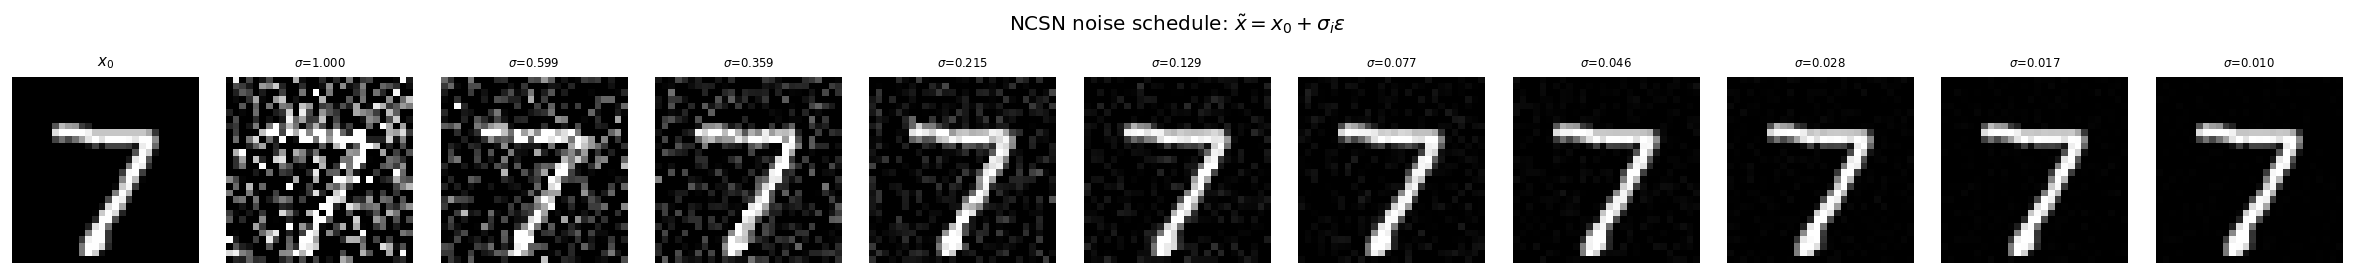

In [4]:
x0, _ = next(iter(test_loader))
x0    = x0[:1].to(DEVICE)   # single image

fig, axes = plt.subplots(1, L + 1, figsize=(1.8 * (L+1), 2.2))
axes[0].imshow(denormalize(x0).squeeze().cpu(), cmap='gray', vmin=0, vmax=1)
axes[0].set_title('$x_0$', fontsize=9)
axes[0].axis('off')

for j, sigma in enumerate(sigmas):
    noise   = torch.randn_like(x0) * sigma.to(DEVICE)
    x_noisy = (x0 + noise).clamp(-2, 2)   # for display
    axes[j+1].imshow(denormalize(x_noisy).squeeze().cpu(), cmap='gray', vmin=0, vmax=1)
    axes[j+1].set_title(f'$\\sigma$={sigma:.3f}', fontsize=7)
    axes[j+1].axis('off')

fig.suptitle(r'NCSN noise schedule: $\tilde{x} = x_0 + \sigma_i\varepsilon$', y=1.02)
plt.tight_layout()
plt.show()

### 1b  Train NCSN

In [5]:
from diffusion_lab.training import Trainer
from diffusion_lab.utils   import plot_loss_curve

trainer_ncsn = Trainer(
    model=ncsn,
    loader=train_loader,
    lr=2e-4,
    grad_clip=1.0,
    device=DEVICE,
)

N_STEPS = 20_000   # ← reduce to 2000 for a quick smoke test
losses_ncsn = trainer_ncsn.train(n_steps=N_STEPS, log_every=500)
print(f'Initial: {losses_ncsn[0]:.4f}   Final: {losses_ncsn[-1]:.4f}')

Training:   0%|          | 0/20000 [00:00<?, ?it/s]

Initial: 0.9952   Final: 0.1182


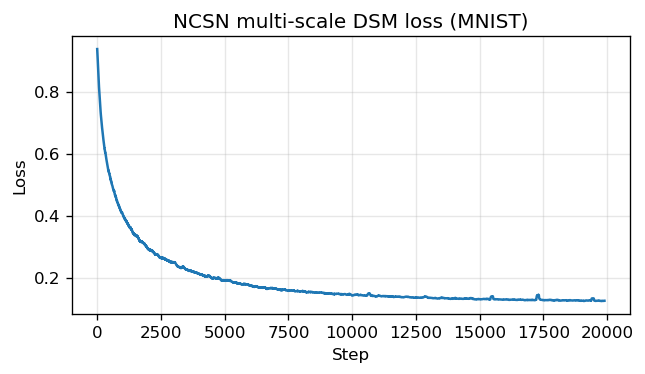

In [6]:
plot_loss_curve(losses_ncsn, smooth=100, title='NCSN multi-scale DSM loss (MNIST)')
plt.show()

### 1c  Learned score field — arrows on noisy images

The score $s_\theta(\tilde{x}, \sigma_i) \approx \nabla_{\tilde{x}}\log q_{\sigma_i}(\tilde{x})$ should
point from the corrupted image back toward the clean data manifold.

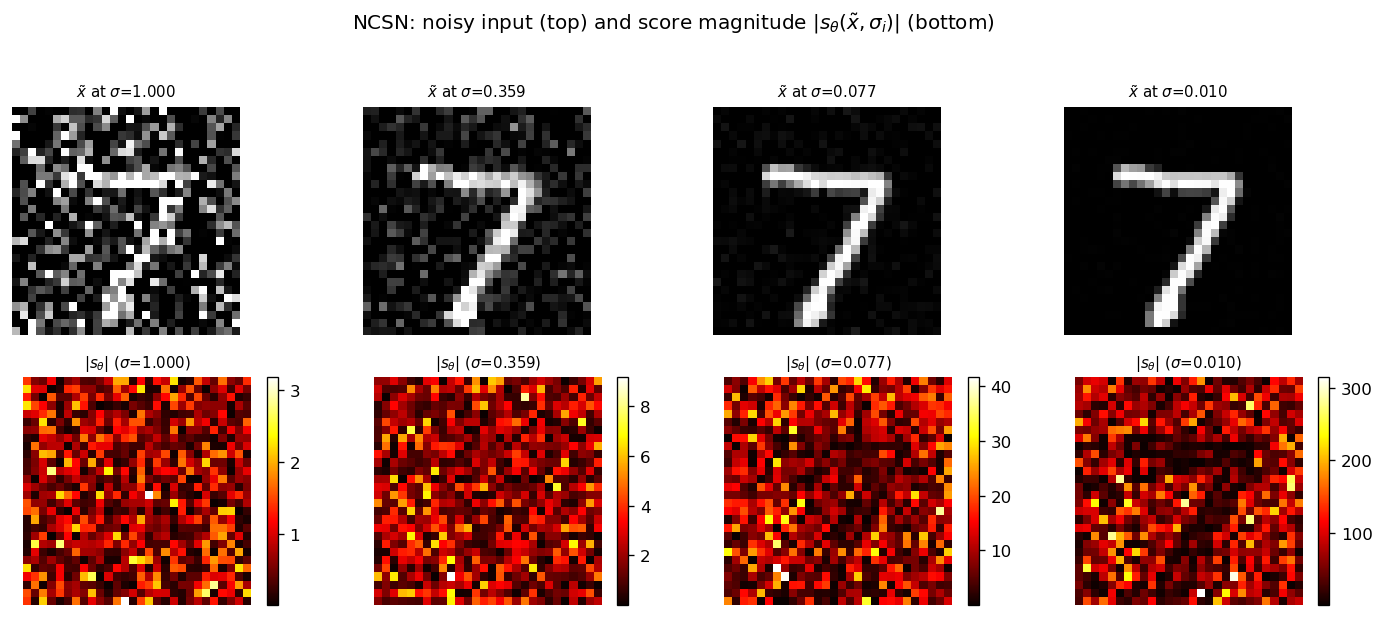

In [7]:
ncsn.eval()
sigma_max_t = sigmas[0].to(DEVICE)

# Show score magnitude as image overlay for a few noise levels
show_levels = [0, 2, 5, 9]   # indices into sigmas

fig, axes = plt.subplots(2, len(show_levels), figsize=(3 * len(show_levels), 5))

for col, i in enumerate(show_levels):
    sigma_i  = sigmas[i].to(DEVICE)
    eps      = torch.randn_like(x0)
    x_noisy  = x0 + eps * sigma_i
    t_input  = (sigma_i / sigma_max_t).unsqueeze(0).expand(1)

    with torch.no_grad():
        score = ncsn.network(x_noisy, t_input)   # (1, 1, 28, 28)

    # Top row: noisy input
    axes[0, col].imshow(denormalize(x_noisy).squeeze().cpu(), cmap='gray', vmin=0, vmax=1)
    axes[0, col].set_title(f'$\\tilde{{x}}$ at $\\sigma$={sigma_i.item():.3f}', fontsize=9)
    axes[0, col].axis('off')

    # Bottom row: score magnitude (higher = stronger push toward data)
    score_mag = score.abs().squeeze().cpu()
    im = axes[1, col].imshow(score_mag, cmap='hot')
    plt.colorbar(im, ax=axes[1, col], fraction=0.046)
    axes[1, col].set_title(f'$|s_\\theta|$ ($\\sigma$={sigma_i.item():.3f})', fontsize=9)
    axes[1, col].axis('off')

fig.suptitle(r'NCSN: noisy input (top) and score magnitude $|s_\theta(\tilde{x},\sigma_i)|$ (bottom)',
             y=1.02)
plt.tight_layout()
plt.show()

### 1d  Annealed Langevin dynamics — sampling chain

In [8]:
# Collect snapshots after each noise level
chain_ncsn = ncsn.annealed_langevin(
    shape=(64, 1, 28, 28),
    device=DEVICE,
    n_steps_per_level=500,
    step_lr=1e-5,
    return_chain=True,
    chain_levels=list(range(L)),
)
print(f'Chain frames: {len(chain_ncsn)}')

Chain frames: 10


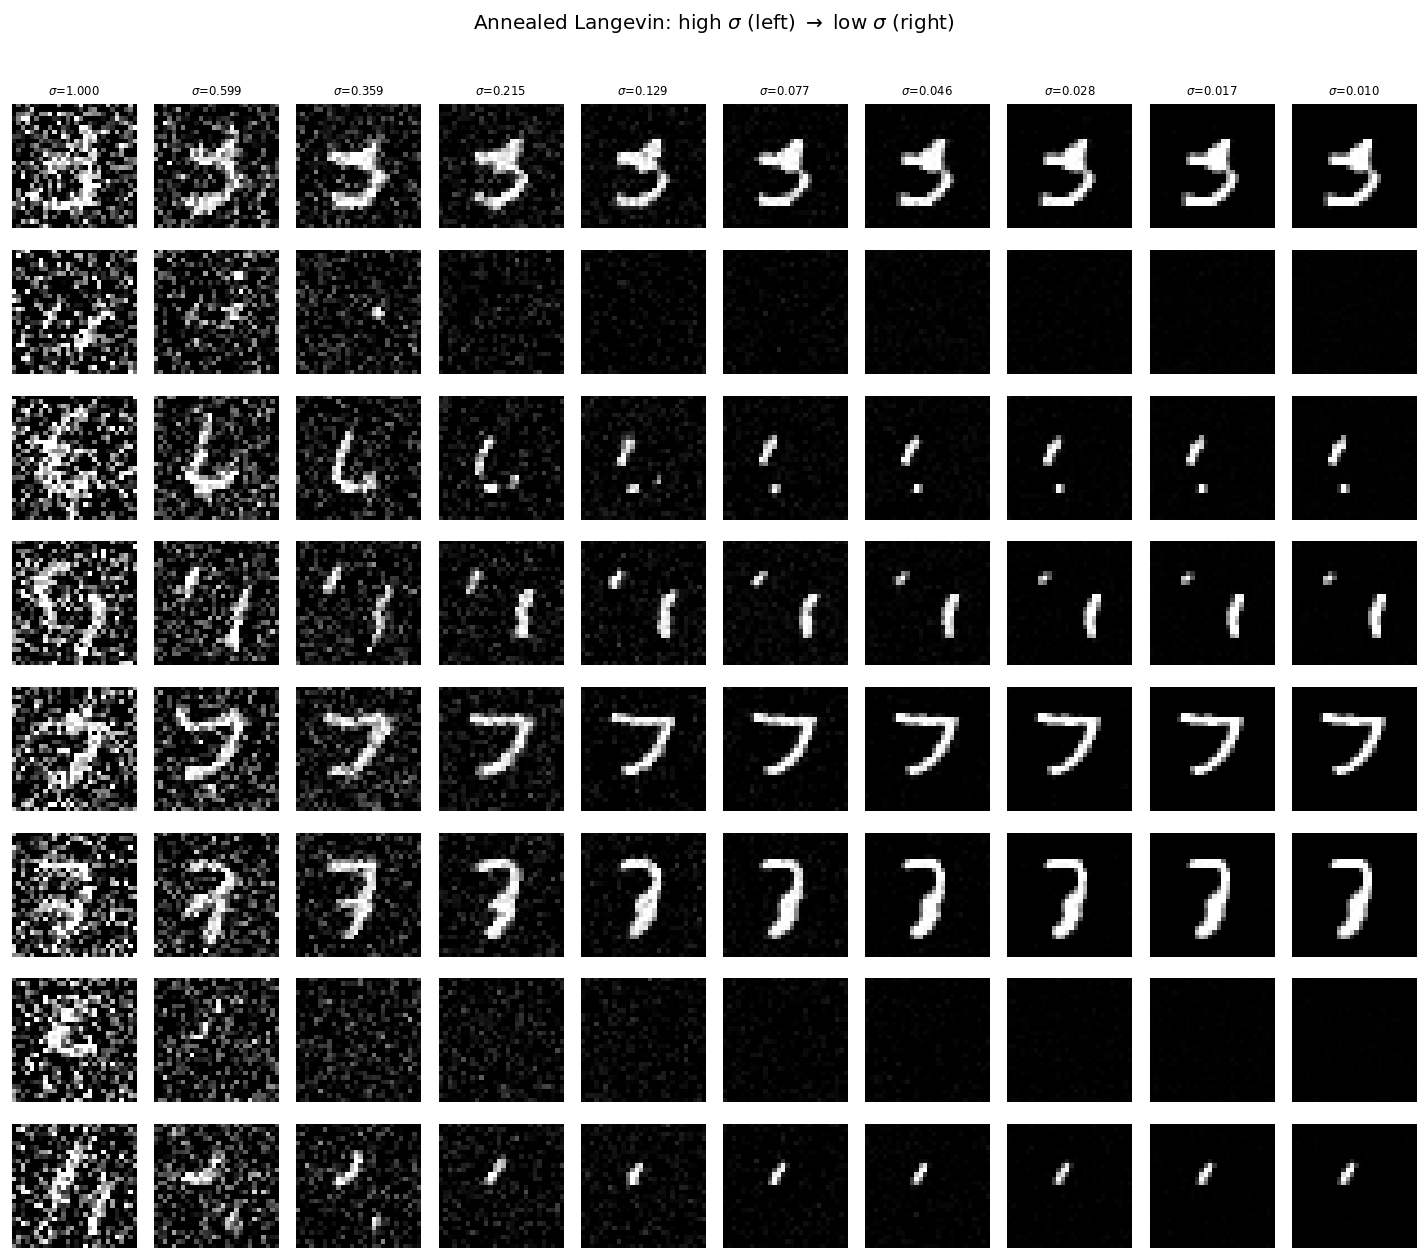

In [9]:
# Show the annealing progression for 8 samples across all L noise levels
n_show_rows = 8
fig, axes = plt.subplots(n_show_rows, L, figsize=(L * 1.2, n_show_rows * 1.3))

for col, frame in enumerate(chain_ncsn):
    imgs = denormalize(frame[:n_show_rows]).numpy()   # clamp for display
    for row in range(n_show_rows):
        axes[row, col].imshow(imgs[row, 0], cmap='gray', vmin=0, vmax=1)
        axes[row, col].axis('off')
    axes[0, col].set_title(f'$\\sigma$={sigmas[col]:.3f}', fontsize=7)

fig.suptitle('Annealed Langevin: high $\\sigma$ (left) $\\to$ low $\\sigma$ (right)', y=1.01)
plt.tight_layout()
plt.show()

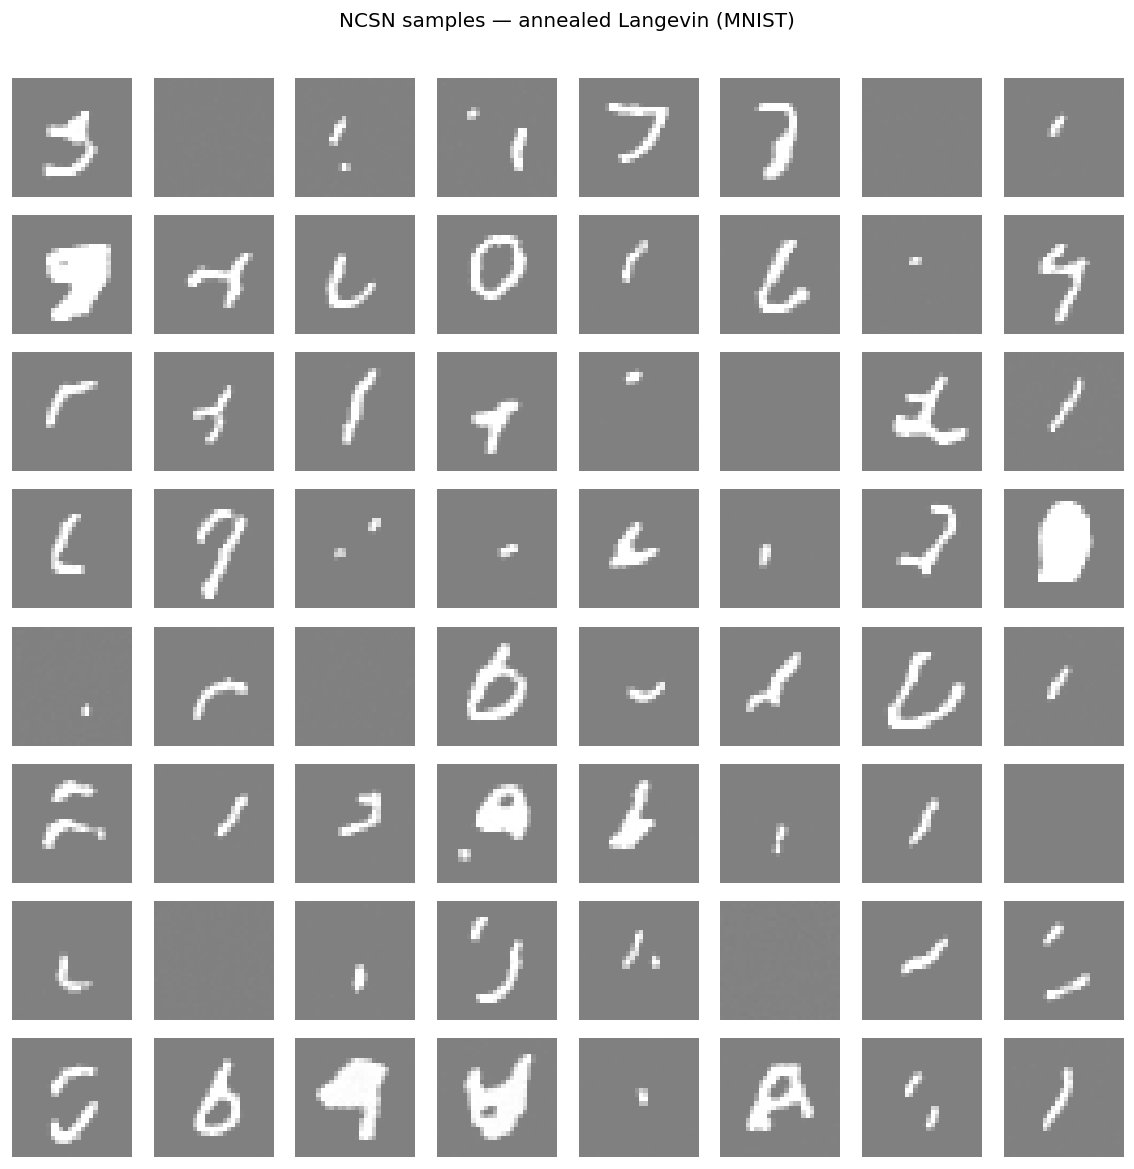

In [10]:
# Final samples grid
x_ncsn = chain_ncsn[-1]   # samples at σ_L (lowest noise)
fig = show_grid(
    denormalize(x_ncsn).clamp(0, 1),
    nrow=8,
    title='NCSN samples — annealed Langevin (MNIST)',
)
plt.show()

## 2  VE-SDE — Continuous-time score model

The VE-SDE generalizes NCSN to continuous time:
$$\sigma(t) = \sigma_{\min}\left(\frac{\sigma_{\max}}{\sigma_{\min}}\right)^t, \qquad t\in[0,1]$$
At $t=0$: near-clean data. At $t=1$: highly corrupted ($\sigma_{\max}=5$ for MNIST).

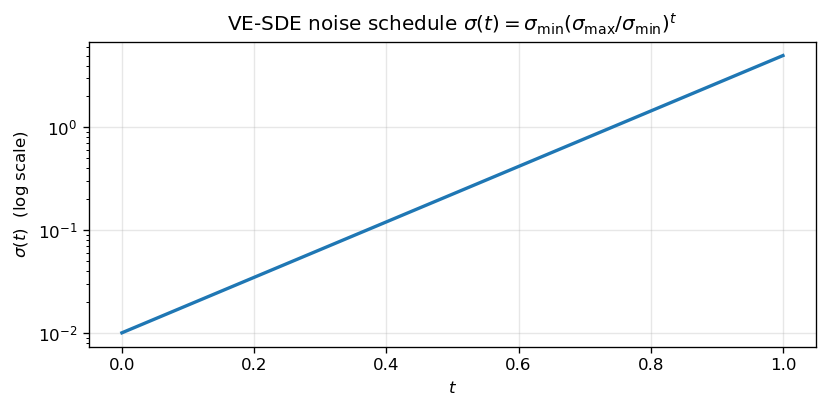

In [11]:
from diffusion_lab.models import VE_SDE

# Separate network for VE-SDE
score_net_ve = SmallUNet(
    in_channels=1,
    out_channels=1,
    base_channels=32,
    time_embed_dim=128,
    dropout=0.1,
).to(DEVICE)

ve_sde = VE_SDE(
    network=score_net_ve,
    sigma_min=0.01,
    sigma_max=5.0,    # higher than NCSN to fully destroy image structure
).to(DEVICE)

# Show the σ(t) schedule
t_vals = np.linspace(0, 1, 200)
sigma_t = ve_sde.sigma_min * (ve_sde.sigma_max / ve_sde.sigma_min) ** t_vals

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.semilogy(t_vals, sigma_t, linewidth=2)
ax.set_xlabel('$t$')
ax.set_ylabel(r'$\sigma(t)$  (log scale)')
ax.set_title(r'VE-SDE noise schedule $\sigma(t) = \sigma_{\min}(\sigma_{\max}/\sigma_{\min})^t$')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 2a  Train VE-SDE

In [12]:
trainer_ve = Trainer(
    model=ve_sde,
    loader=train_loader,
    lr=2e-4,
    grad_clip=1.0,
    device=DEVICE,
)

losses_ve = trainer_ve.train(n_steps=N_STEPS, log_every=500)
print(f'Initial: {losses_ve[0]:.4f}   Final: {losses_ve[-1]:.4f}')

Training:   0%|          | 0/20000 [00:00<?, ?it/s]

Initial: 0.9992   Final: 0.0993


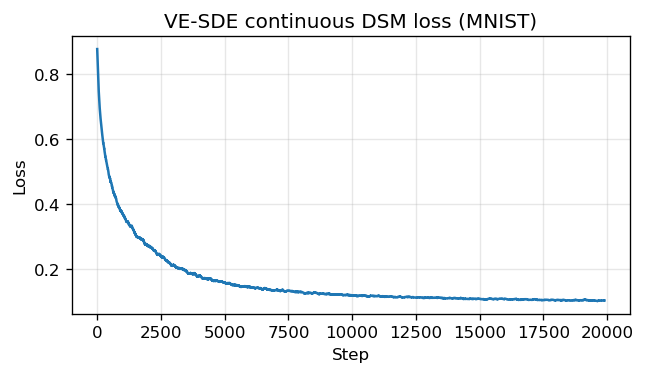

In [13]:
plot_loss_curve(losses_ve, smooth=100, title='VE-SDE continuous DSM loss (MNIST)')
plt.show()

### 2b  Reverse SDE (stochastic) vs. Probability Flow ODE (deterministic)

Both samplers yield samples from the same marginal $p_0 = p_{\text{data}}$,  
but the ODE is deterministic (encoder-decoder structure) while the SDE is stochastic.

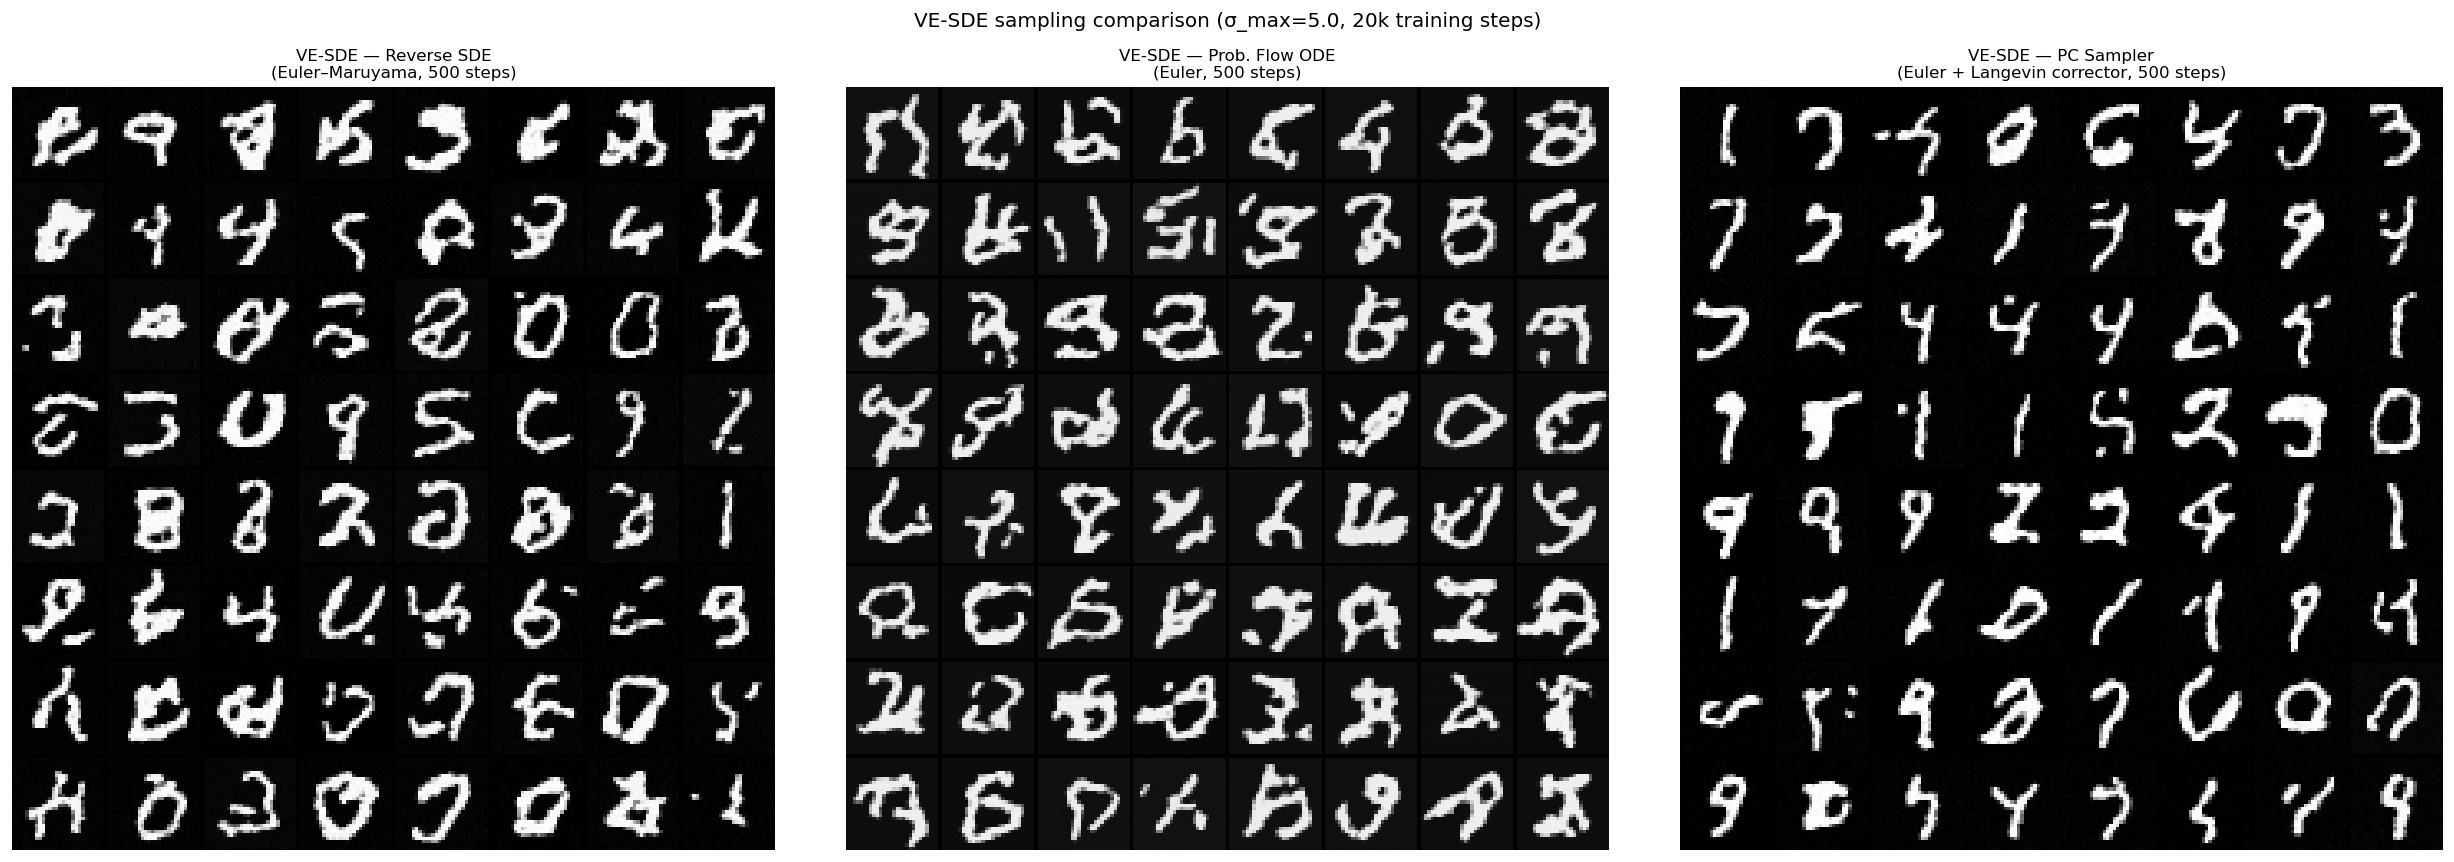

In [14]:
ve_sde.eval()

with torch.no_grad():
    x_sde = ve_sde.reverse_sde_sample(
        shape=(64, 1, 28, 28),
        device=DEVICE,
        n_steps=500,
    )
    x_ode = ve_sde.ode_sample(
        shape=(64, 1, 28, 28),
        device=DEVICE,
        n_steps=500,
    )
    x_pc = ve_sde.pc_sample(
        shape=(64, 1, 28, 28),
        device=DEVICE,
        n_steps=500,
        n_corrector=1,
        target_snr=0.16,
    )

samplers = [
    ('VE-SDE — Reverse SDE\n(Euler–Maruyama, 500 steps)',         x_sde),
    ('VE-SDE — Prob. Flow ODE\n(Euler, 500 steps)',                x_ode),
    ('VE-SDE — PC Sampler\n(Euler + Langevin corrector, 500 steps)', x_pc),
]

fig, axes = plt.subplots(1, 3, figsize=(21, 7))

for ax, (title, imgs) in zip(axes, samplers):
    img_np = denormalize(imgs[:64]).clamp(0, 1).cpu().numpy()
    grid   = np.zeros((8 * 29 - 1, 8 * 29 - 1))
    for i in range(8):
        for j in range(8):
            grid[i*29:(i+1)*29-1, j*29:(j+1)*29-1] = img_np[i*8+j, 0]
    ax.imshow(grid, cmap='gray', vmin=0, vmax=1)
    ax.set_title(title, fontsize=10)
    ax.axis('off')

fig.suptitle('VE-SDE sampling comparison (σ_max=5.0, 20k training steps)', y=1.02)
plt.tight_layout()
plt.show()

### 2c  Reverse SDE chain — denoising progression

SDE chain frames: 11


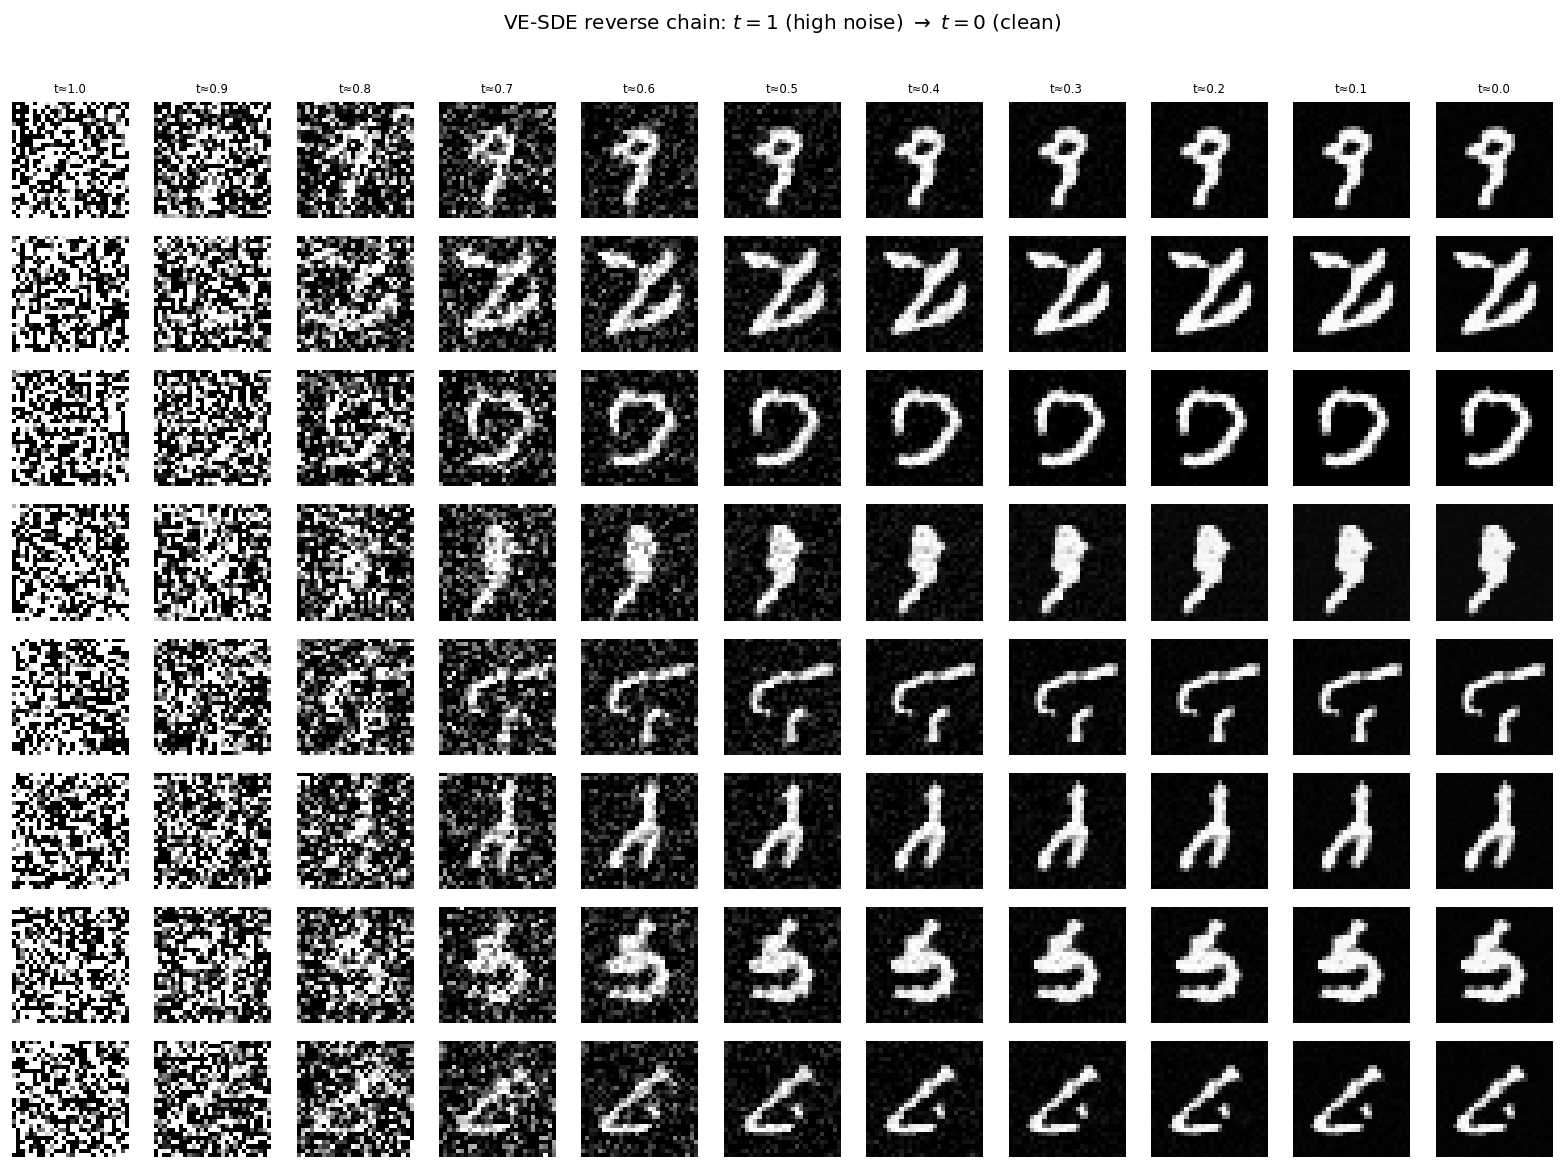

In [15]:
with torch.no_grad():
    chain_sde = ve_sde.reverse_sde_sample(
        shape=(8, 1, 28, 28),
        device=DEVICE,
        n_steps=500,
        return_chain=True,
        chain_stride=50,   # ~10 snapshots
    )

n_frames = len(chain_sde)
print(f'SDE chain frames: {n_frames}')

fig, axes = plt.subplots(8, n_frames, figsize=(n_frames * 1.2, 8 * 1.2))
for col, frame in enumerate(chain_sde):
    imgs = denormalize(frame).numpy()
    t_approx = 1.0 - col / (n_frames - 1)
    for row in range(8):
        axes[row, col].imshow(imgs[row, 0], cmap='gray', vmin=0, vmax=1)
        axes[row, col].axis('off')
    axes[0, col].set_title(f't≈{t_approx:.1f}', fontsize=7)

fig.suptitle('VE-SDE reverse chain: $t=1$ (high noise) $\\to$ $t=0$ (clean)', y=1.01)
plt.tight_layout()
plt.show()

## 3  NCSN vs. VE-SDE vs. DDPM — three-way comparison

Load DDPM checkpoint from notebook 05 for a fair comparison.

In [16]:
from diffusion_lab.models     import DDPM, DDIMSampler
from diffusion_lab.schedulers import cosine_vp_schedule

ckpt_path = pathlib.Path('../checkpoints/ddpm_mnist.pt')

import pathlib
unet_ddpm = SmallUNet(in_channels=1, out_channels=1,
                      base_channels=32, time_embed_dim=128).to(DEVICE)
ddpm      = DDPM(unet_ddpm, cosine_vp_schedule(T=1000).to(DEVICE)).to(DEVICE)

if ckpt_path.exists():
    trainer_tmp = Trainer(ddpm, train_loader, device=DEVICE)
    trainer_tmp.load(str(ckpt_path))
    print(f'Loaded DDPM from {ckpt_path}')
else:
    print('No checkpoint — training DDPM (5000 steps)...')
    trainer_tmp = Trainer(ddpm, train_loader, lr=2e-4, device=DEVICE)
    trainer_tmp.train(n_steps=5_000, log_every=1000)

ddpm.eval()

Loaded DDPM from ../checkpoints/ddpm_mnist.pt


DDPM(
  (network): SmallUNet(
    (time_embed): Sequential(
      (0): SinusoidalEmbedding()
      (1): Linear(in_features=128, out_features=512, bias=True)
      (2): SiLU()
      (3): Linear(in_features=512, out_features=128, bias=True)
    )
    (stem): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (enc1): ResBlock(
      (adagn1): AdaGN(
        (norm): GroupNorm(8, 32, eps=1e-06, affine=False)
        (proj): Sequential(
          (0): SiLU()
          (1): Linear(in_features=128, out_features=64, bias=True)
        )
      )
      (conv1): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (adagn2): AdaGN(
        (norm): GroupNorm(8, 64, eps=1e-06, affine=False)
        (proj): Sequential(
          (0): SiLU()
          (1): Linear(in_features=128, out_features=128, bias=True)
        )
      )
      (drop): Dropout(p=0.1, inplace=False)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(

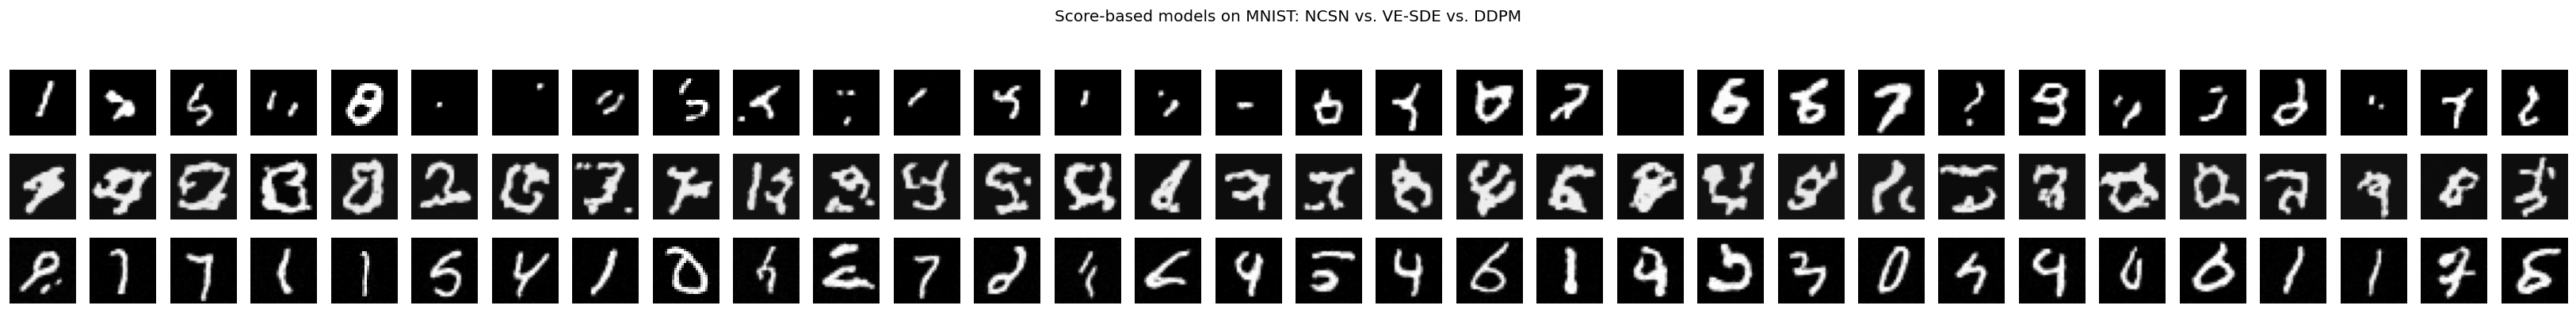

In [17]:
# Generate 32 samples from each approach
N_CMP = 32

with torch.no_grad():
    x_ncsn_final = ncsn.annealed_langevin(
        shape=(N_CMP, 1, 28, 28), device=DEVICE,
        n_steps_per_level=200, step_lr=2e-5,
    )
    x_ve_ode_final = ve_sde.ode_sample(
        shape=(N_CMP, 1, 28, 28), device=DEVICE, n_steps=200,
    )
    x_ddpm_final = ddpm.sample(
        shape=(N_CMP, 1, 28, 28), device=DEVICE,
    )

# Display
models_results = [
    ('NCSN (Annealed Langevin)',    x_ncsn_final),
    ('VE-SDE (Prob. Flow ODE)',     x_ve_ode_final),
    ('DDPM VP (Ancestral, T=1000)', x_ddpm_final),
]

fig, axes = plt.subplots(len(models_results), N_CMP, figsize=(N_CMP * 0.85, len(models_results) * 1.1))
for row, (title, xs) in enumerate(models_results):
    imgs = denormalize(xs[:N_CMP]).clamp(0, 1).cpu().numpy()
    for col in range(N_CMP):
        axes[row, col].imshow(imgs[col, 0], cmap='gray', vmin=0, vmax=1)
        axes[row, col].axis('off')
    axes[row, 0].set_ylabel(title, rotation=0, labelpad=120, va='center', fontsize=8)

fig.suptitle('Score-based models on MNIST: NCSN vs. VE-SDE vs. DDPM', y=1.02)
plt.tight_layout()
plt.show()

## 4  Save checkpoints

In [18]:
import pathlib
ckpt_dir = pathlib.Path('../checkpoints')
ckpt_dir.mkdir(exist_ok=True)
trainer_ncsn.save(str(ckpt_dir / 'ncsn_mnist.pt'))
trainer_ve.save(str(ckpt_dir / 've_sde_mnist.pt'))
print('Saved: checkpoints/ncsn_mnist.pt, ve_sde_mnist.pt')

Saved: checkpoints/ncsn_mnist.pt, ve_sde_mnist.pt
